## ML (Using Linear Regression) Workflow:
<input type="checkbox" checked id="option1" name="option1" value="yes">
<label for="option1">Import necessary libraries.</label>
<br />
<input type="checkbox" checked id="option2" name="option2" value="yes">
<label for="option2">Reading transformed dataset.</label>
<br />
<input type="checkbox" checked id="option3" name="option3" value="yes">
<label for="option3">Transform categorical columns to numeric.</label>
<br />
<input type="checkbox" checked id="option4" name="option4" value="yes">
<label for="option4">Plotting heatmap on column to figure out which columns have strong relationship.</label>
<br />
<input type="checkbox" checked id="option5" name="option5" value="yes">
<label for="option5">Splitting data to 30% test and 70% train.</label>
<br />
<input type="checkbox" checked id="option6" name="option6" value="yes">
<label for="option6">Creating multiple linear regression.</label>
<br />
<input type="checkbox" checked id="option7" name="option7" value="yes">
<label for="option7">Comparing metrics between Train and Test data to figure out the gap between them.</label>
<br />
<input type="checkbox" checked id="option8" name="option8" value="yes">
<label for="option8">Prediction price on unseen data.</label>
<br />

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_excel("data transformed/data.xlsx")

In [3]:
df.head(3)

,Area,Room,Parking,Warehouse,Elevator,Price,outlier
0,63,1,True,True,True,1850000000,False
1,60,1,True,True,True,1850000000,False
2,79,2,True,True,True,550000000,False


In [4]:
parking_le = LabelEncoder()
df["Parking"] = parking_le.fit_transform(df["Parking"])

warehouse_le = LabelEncoder()
df["Warehouse"] = warehouse_le.fit_transform(df["Warehouse"])

elevator_le = LabelEncoder()
df["Elevator"] = elevator_le.fit_transform(df["Elevator"])

print(f"Parking Classes: {dict(enumerate(parking_le.classes_))}")
print(f"Warehouse Classes: {dict(enumerate(warehouse_le.classes_))}")
print(f"Elevator Classes: {dict(enumerate(elevator_le.classes_))}")

Parking Classes: {0: False, 1: True}
Warehouse Classes: {0: False, 1: True}
Elevator Classes: {0: False, 1: True}


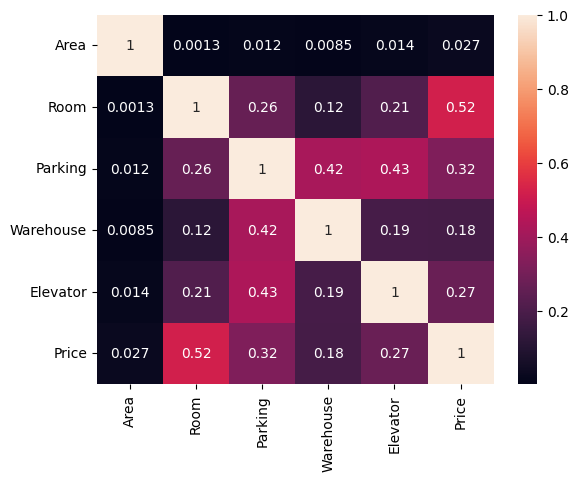

In [5]:
df_corr = df[['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Price']].corr()
sns.heatmap(df_corr,annot=True)
plt.show()

In [6]:
X = df[["Area","Room","Parking","Warehouse","Elevator"]]
y = df[["Price"]]

In [7]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

In [8]:
mlr = LinearRegression()

mlr.fit(x_train,y_train)

LinearRegression()

In [9]:
predicted_mlr_test = mlr.predict(x_test)
predicted_mlr_train = mlr.predict(x_train)

r2_score_test = r2_score(y_test,predicted_mlr_test) * 100
r2_score_train = r2_score(y_train,predicted_mlr_train) * 100

mae = mean_absolute_error(y_test,predicted_mlr_test)
mse = mean_squared_error(y_test,predicted_mlr_test)
rmse = np.sqrt(mse)

In [10]:
print(f"r2_score of test data: {r2_score_test:,.2f}%")
print(f"r2_score of train data: {r2_score_train:,.2f}%")
print(f"Gap between train and test: {r2_score_train - r2_score_test:,.2f}\n")

print(f"MAE: {mae:,.0f}")
print(f"MSE: {mse:,.0f}")
print(f"RMSE: {rmse:,.0f}")

r2_score of test data: 30.52%
r2_score of train data: 32.40%
Gap between train and test: 1.88

MAE: 1,839,185,230
MSE: 5,788,696,760,487,595,008
RMSE: 2,405,971,064


In [11]:
# Area: 65, Room: 2, Parking: Yes, Warehouse: Yes, Elevator: No
unseen = mlr.predict(scale.transform(np.array([[60,2,1,1,0]])))

print(f"Price of new data: {unseen[0][0]:,.0f} Tomans")

Price of new data: 3,088,433,371 Tomans


C:\Users\Administrator\Desktop\projects\Projects\House Price Prediction\venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
